# P2 · 04 — Capstone: machine learning vs classical, head to head

Bring Project 1's best (SARIMA, Holt-Winters) and Project 2's best (gradient boosting
on a growth target, direct & recursive) into **one rolling-origin backtest**, then
produce a final ML forecast with a **quantile-regression interval**.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import ml, baselines as B, backtest as bt, classical as C
q = data.load_quarterly(); y = q["gdp_nsa"]

candidates = {
    "seasonal_naive(4)":      B.seasonal_naive(4),
    "Holt-Winters":           C.ets_forecaster(trend="add", seasonal="add", seasonal_periods=4),
    "SARIMA(1,1,1)(0,1,0)4":  C.sarima_forecaster((1, 1, 1), (0, 1, 0, 4)),
    "GBM growth (recursive)": ml.gbm_recursive_forecaster(target="growth"),
    "GBM growth (direct)":    ml.gbm_direct_forecaster(target="growth"),
}
board = bt.compare(y, candidates, initial=40, h=4, step=1, season_length=4)
print(board.round(3).to_string())
print("\nWinner by MASE:", board.index[0])

                                MAE         RMSE   MAPE  sMAPE   MASE
SARIMA(1,1,1)(0,1,0)4   2004034.387  4178715.528  3.693  3.763  0.612
Holt-Winters            2097819.195  3929438.519  3.809  3.771  0.640
GBM growth (direct)     2193241.830  3873473.644  3.917  3.876  0.669
GBM growth (recursive)  2683247.087  4508709.444  4.582  4.597  0.819
seasonal_naive(4)       4138715.808  4655608.591  7.221  7.392  1.263

Winner by MASE: SARIMA(1,1,1)(0,1,0)4


### The honest verdict

On **88 points of one clean, smooth series**, the tuned **SARIMA usually wins**, with
gradient boosting a close, respectable second. That is *not* a knock on ML — it's the
right read of the situation:

* **Classical shines** when you have one well-behaved series with clear trend +
  seasonality and little else. Few parameters, strong structure, hard to beat.
* **ML shines** when you have **many related series**, **exogenous drivers** (rates,
  weather, promotions), **nonlinearities/interactions**, or **long histories** — none
  of which a univariate GDP series exercises. P2 built exactly the machinery (feature
  tables, multi-step, leakage-safe CV) that scales to those problems.

### Final ML forecast with a prediction interval (quantile regression)

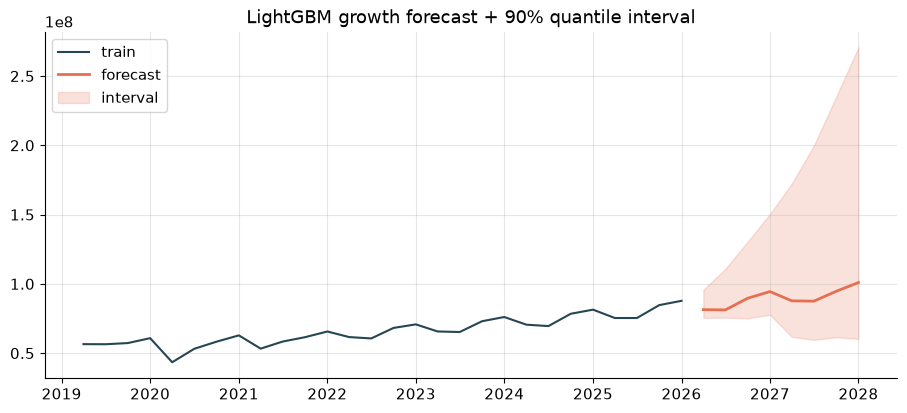

,forecast,low,high
2026Q2,81396287.0,75502739.0,95715677.0
2026Q3,81208562.0,75606915.0,110890427.0
2026Q4,89622721.0,75144582.0,130508821.0
2027Q1,94445813.0,77672107.0,150336728.0
2027Q2,87754823.0,61769995.0,172391135.0
2027Q3,87527764.0,59594437.0,199722001.0
2027Q4,94630015.0,61441875.0,235056206.0
2028Q1,100979101.0,60303246.0,270767758.0


In [2]:
H = 8
mid, lo, hi = ml.gbm_quantile_forecast(y, H, alpha=0.05)
future = pd.period_range(y.index.max() + 1, periods=H, freq="Q")
fc = pd.Series(mid, index=future)
lo = pd.Series(lo, index=future); hi = pd.Series(hi, index=future)
fig, ax = plt.subplots()
plots.plot_forecast(y.iloc[-28:], pred=fc, lower=lo, upper=hi,
                    title="LightGBM growth forecast + 90% quantile interval", ax=ax)
plots.save(fig, "p2_ml_forecast"); plt.show()
pd.DataFrame({"forecast": fc.round(0), "low": lo.round(0), "high": hi.round(0)})

Quantile regression gives an interval **for free** (fit the 5th/50th/95th-percentile
losses), and it needn't be symmetric. Caveats you should say out loud: separately-fit
quantiles can **cross**, and recursive quantile forecasts **widen fast** because
growth uncertainty compounds. Project 3 replaces this with calibrated, guaranteed-
coverage intervals (**conformal prediction**) and proper probabilistic scoring.

### Project 2 — what you can now do

1. Reframe any forecasting problem as a **supervised table** (lags, rolling, calendar,
   Fourier) without leakage.
2. Avoid the **extrapolation trap** by forecasting a **stationary target**.
3. Choose and implement **recursive vs direct** multi-step strategies.
4. **Interpret** and **regularise** a gradient-boosted forecaster, judged by a proper
   time-series backtest.
5. Know **when ML beats classical** — and when it doesn't.

---
**Next — Project 3:** probabilistic forecasting — quantile loss done right, calibration,
and conformal prediction intervals with coverage guarantees.